In [ ]:
import random
import numpy as np
import matplotlib.pyplot as plt

random.seed(42)
np.random.seed(42)

LANE_WIDTH = 5        # possible lane positions: 0 to 4
EPISODE_LEN = 40       # max steps per simulated drive
SENSOR_RANGE = 3       # agent senses 3 positions ahead
N_GENES = LANE_WIDTH * (2 ** SENSOR_RANGE)   # genome length
ACTIONS = [-1, 0, 1]   # -1 = move left, 0 = stay, 1 = move right

print("Genome length (N_GENES):", N_GENES)

def random_genome():
    return [random.choice(ACTIONS) for _ in range(N_GENES)]

# sanity check
g = random_genome()
print("Sample genome (first 10 genes):", g[:10])
print("Total genome length:", len(g))

Genome length (N_GENES): 40
Sample genome (first 10 genes): [1, -1, -1, 1, 0, -1, -1, -1, 1, -1]
Total genome length: 40


In [ ]:
def run_episode(genome, seed=None):
    rng = random.Random(seed)
    position = LANE_WIDTH // 2   # start in the middle lane
    survived = 0

    # pre-generate obstacle layout for the whole episode
    lanes_ahead = [[rng.random() < 0.25 for _ in range(LANE_WIDTH)] for _ in range(EPISODE_LEN)]

    for t in range(EPISODE_LEN):
        row = lanes_ahead[t]

        # build the sensed obstacle pattern (bitstring of SENSOR_RANGE positions ahead)
        pattern = 0
        for i in range(SENSOR_RANGE):
            idx = min(position + i, LANE_WIDTH - 1)
            pattern = (pattern << 1) | int(row[idx])

        # look up the action for (position, pattern) in the genome
        action = genome[position * (2**SENSOR_RANGE) + pattern]
        position = max(0, min(LANE_WIDTH - 1, position + action))

        if row[position]:
            break   # crashed into an obstacle
        survived += 1

    return survived

# sanity check with a random genome
test_genome = random_genome()
print("Survival time for a random genome (seed=0):", run_episode(test_genome, seed=0))
print("Survival time for a random genome (seed=1):", run_episode(test_genome, seed=1))

Survival time for a random genome (seed=0): 20
Survival time for a random genome (seed=1): 5


In [ ]:
def fitness(genome):
    # average survival time over 5 different seeded episodes for a stable estimate
    return np.mean([run_episode(genome, seed=s) for s in range(5)])

def crossover(g1, g2):
    point = random.randint(1, N_GENES - 1)
    return g1[:point] + g2[point:]

def mutate(genome, rate=0.03):
    return [random.choice(ACTIONS) if random.random() < rate else g for g in genome]

# --- Genetic Algorithm main loop ---
POP_SIZE = 80
N_GENERATIONS = 40
N_ELITES = 12

population = [random_genome() for _ in range(POP_SIZE)]
best_scores = []

for gen in range(N_GENERATIONS):
    # 1. Evaluate fitness of every genome, sort best-first
    scored = sorted(population, key=fitness, reverse=True)

    # 2. Track the best score this generation
    best_scores.append(fitness(scored[0]))

    # 3. Select the elite (top performers)
    elites = scored[:N_ELITES]

    # 4. Generate the rest of the new population via crossover + mutation
    new_pop = elites.copy()
    while len(new_pop) < POP_SIZE:
        p1, p2 = random.sample(elites, 2)
        child = mutate(crossover(p1, p2))
        new_pop.append(child)

    population = new_pop

    if gen % 5 == 0 or gen == N_GENERATIONS - 1:
        print(f"Generation {gen:2d}: best avg survival = {best_scores[-1]:.1f} / {EPISODE_LEN}")

Generation  0: best avg survival = 10.4 / 40
Generation  5: best avg survival = 30.6 / 40
Generation 10: best avg survival = 30.6 / 40
Generation 15: best avg survival = 30.6 / 40
Generation 20: best avg survival = 30.6 / 40
Generation 25: best avg survival = 30.6 / 40
Generation 30: best avg survival = 31.4 / 40
Generation 35: best avg survival = 31.4 / 40
Generation 39: best avg survival = 31.4 / 40


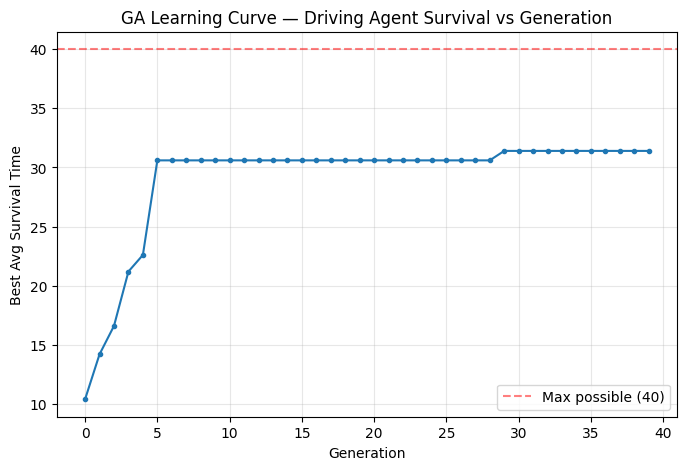

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(range(N_GENERATIONS), best_scores, marker='o', markersize=3)
plt.xlabel("Generation")
plt.ylabel("Best Avg Survival Time")
plt.title("GA Learning Curve — Driving Agent Survival vs Generation")
plt.grid(alpha=0.3)
plt.axhline(y=EPISODE_LEN, color='r', linestyle='--', alpha=0.5, label=f"Max possible ({EPISODE_LEN})")
plt.legend()
plt.show()